## CBM Score Comparison: With vs Without Minus Points (per task)
This notebook compares CBM scores per task using two scoring methods:
- **With minus points** (CBM matrix with R, P, M — no F)
- **Without minus points** (M and F replaced with 0)

In [7]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

root_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils").exists()), None)
if root_path is None:
    raise FileNotFoundError("Could not locate project root containing 'utils' directory")
sys.path.append(str(root_path))

from utils.helpers import load_data
from utils.CBM_score_per_task import CBM_score_per_task_konte_no_F, CBM_score_per_task_konte_no_minus_points

In [8]:
df = load_data("../data/CBM_format/IN1020_2025konte_CBM.csv")
df = df[['student_id', 'question_number', 'answer_alternative', 'confidence_level', 'auto_score', 'total_score']]
df.head()

Data loaded successfully from ../data/CBM_format/IN1020_2025konte_CBM.csv


,student_id,question_number,answer_alternative,confidence_level,auto_score,total_score
0,38,2.1,1,100.0,20.0,68.25
1,38,2.1,4,0.0,20.0,68.25
2,38,2.1,3,0.0,20.0,68.25
3,38,2.1,5,0.0,20.0,68.25
4,38,2.1,2,0.0,20.0,68.25


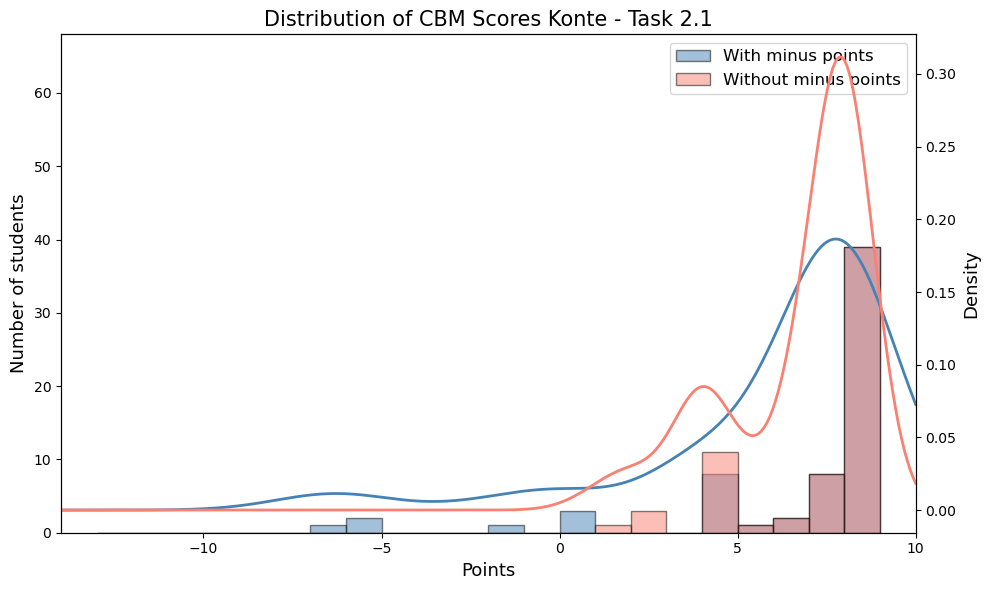

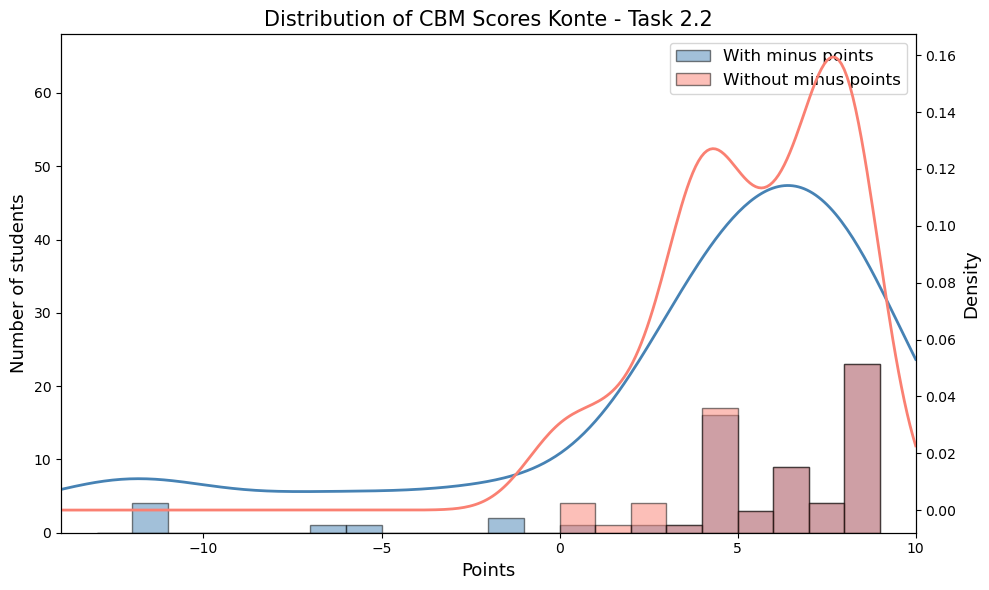

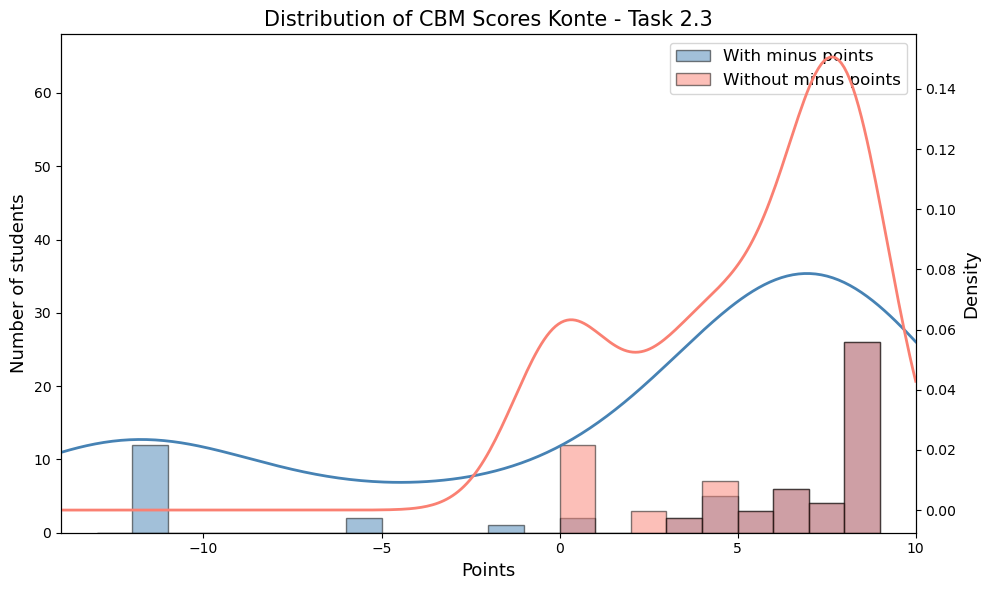

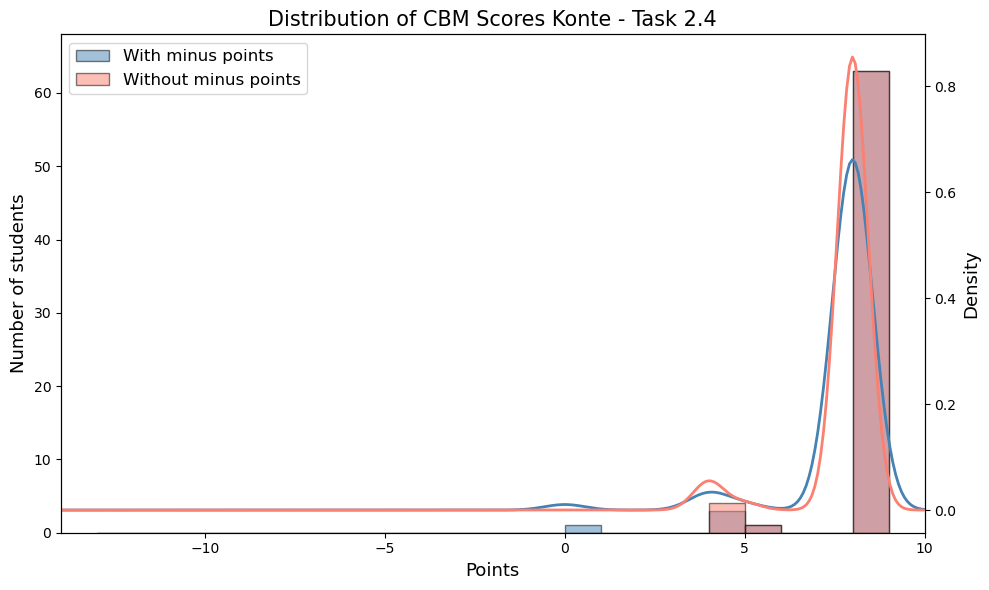

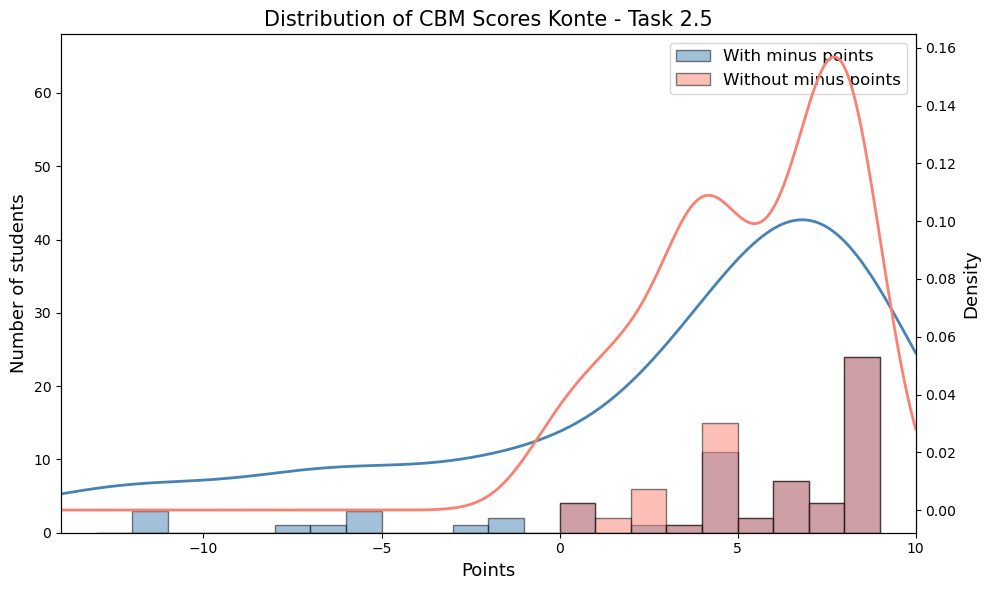

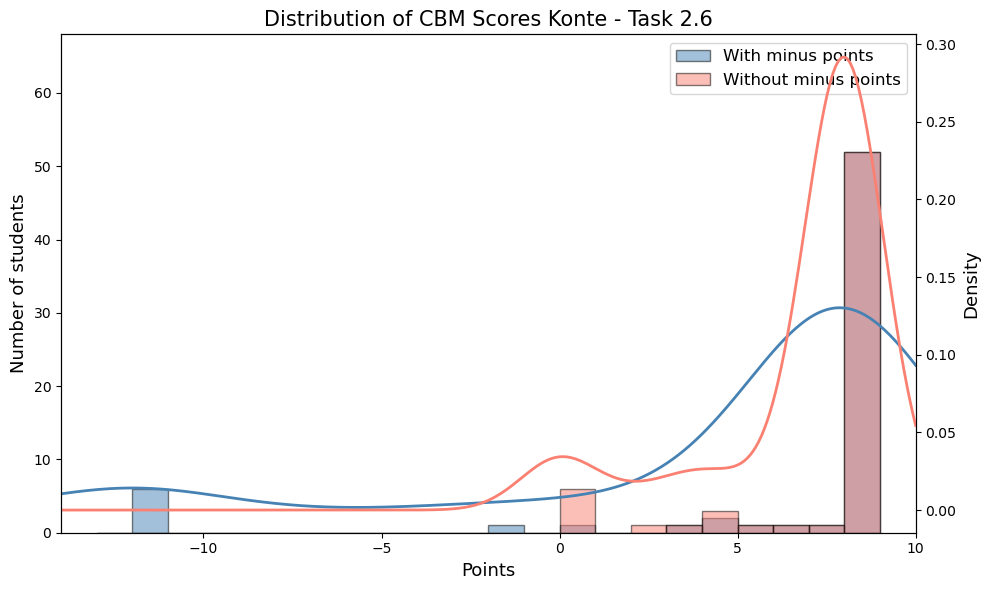

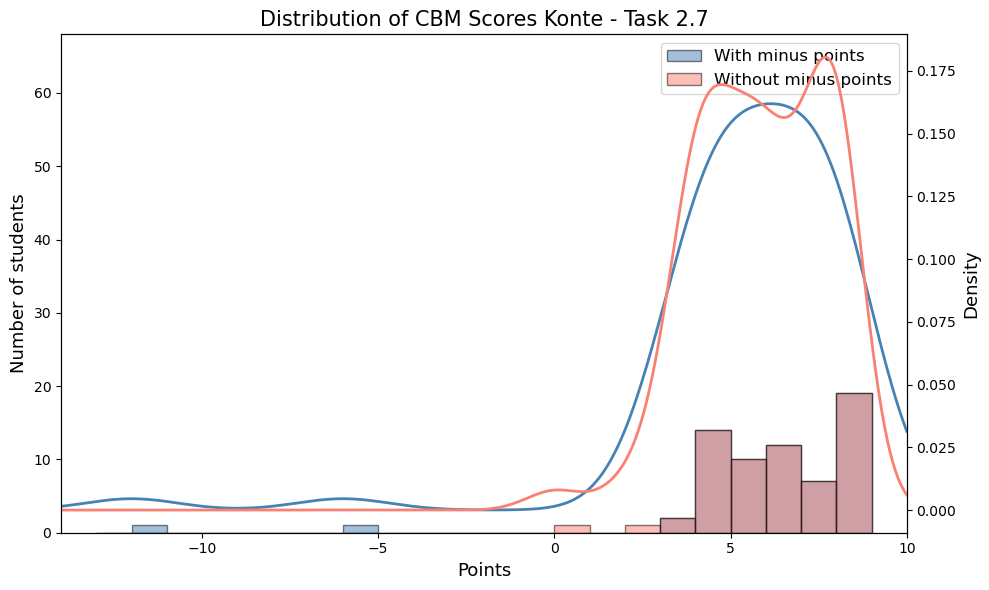

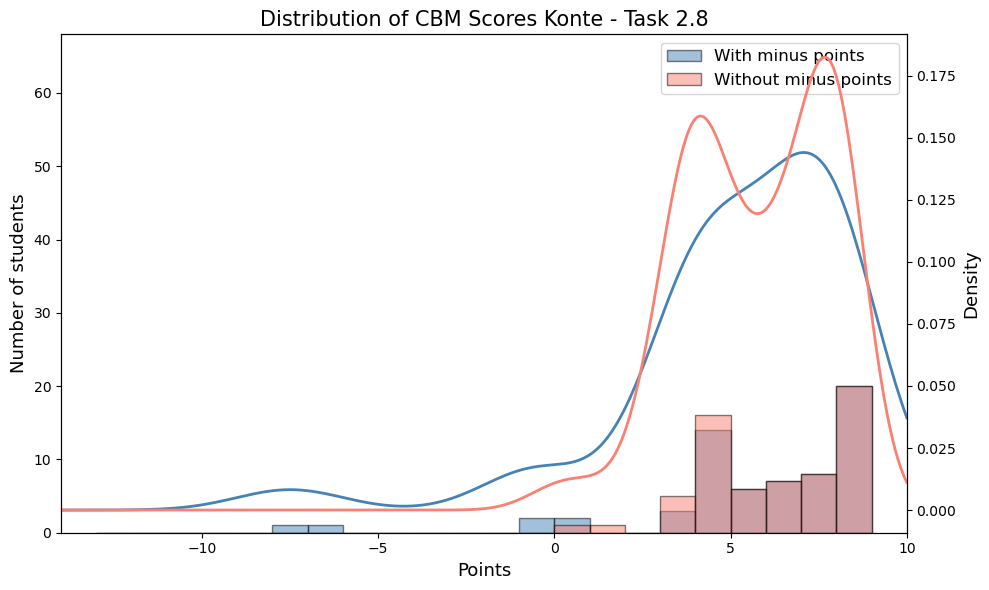

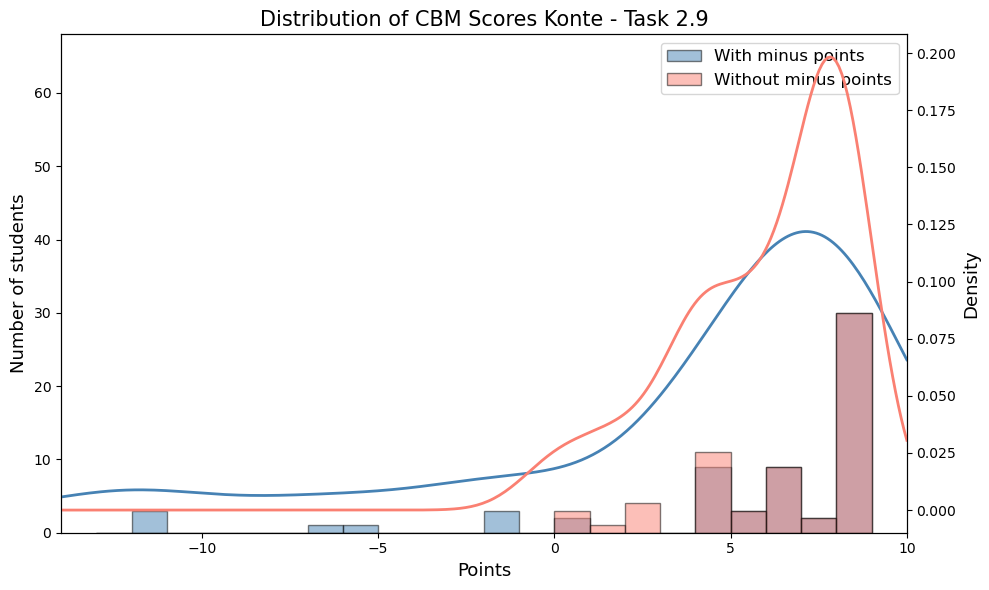

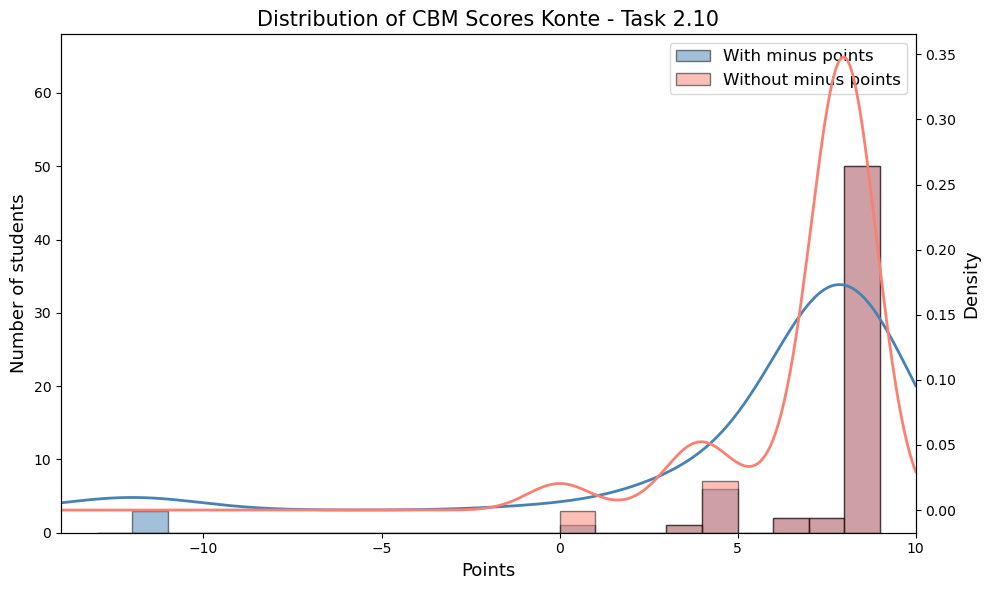

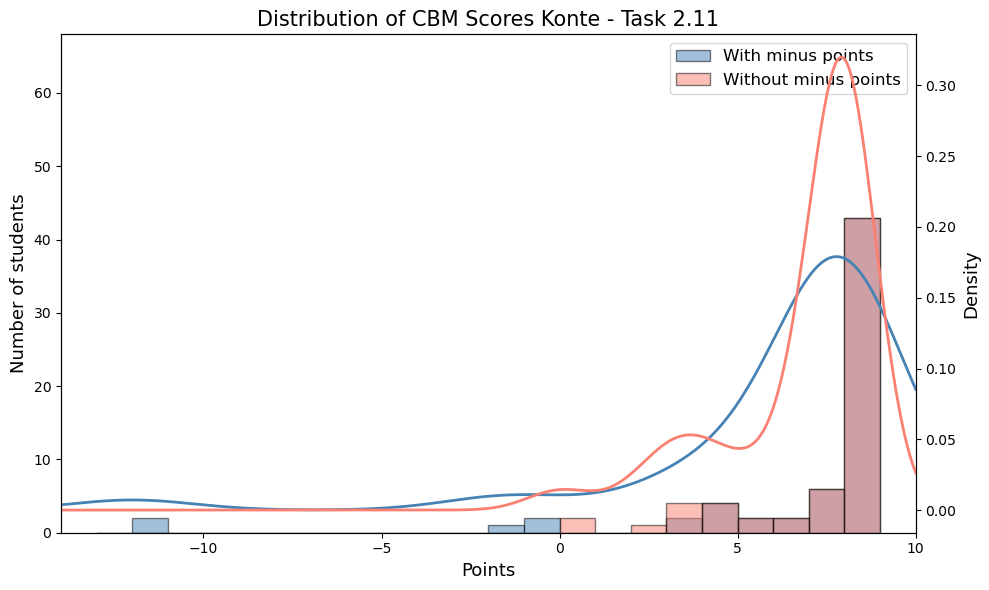

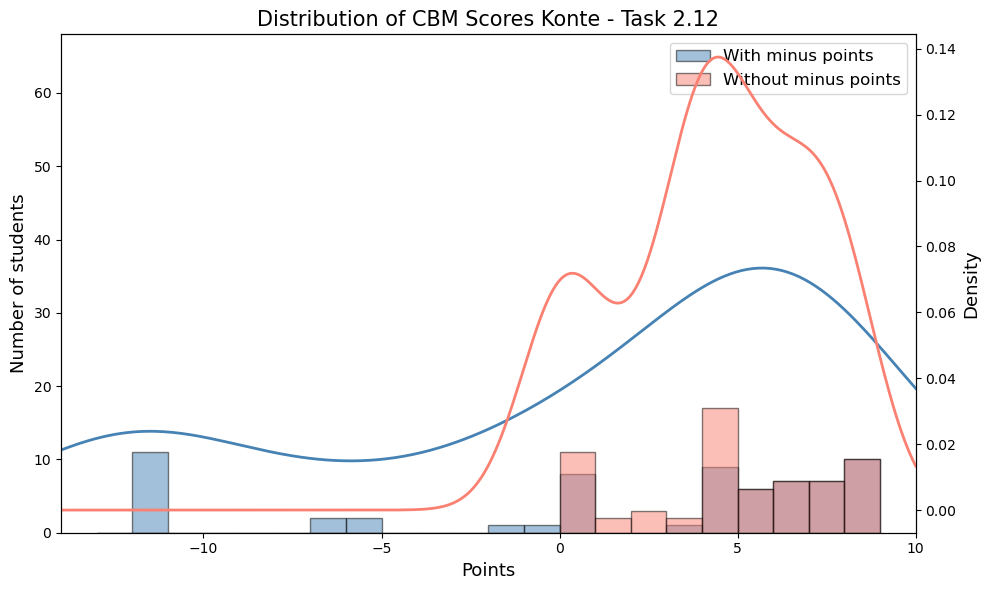

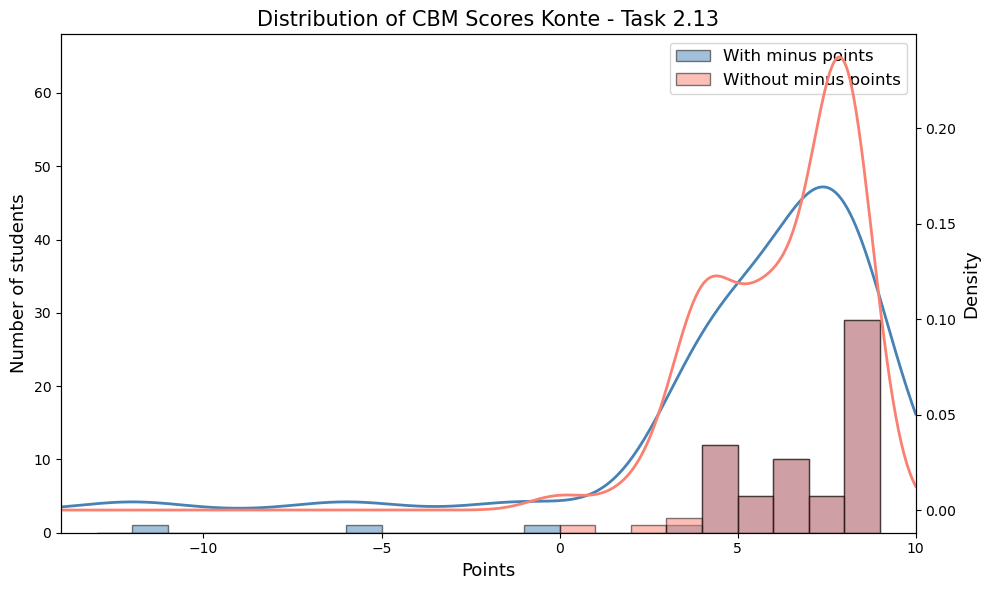

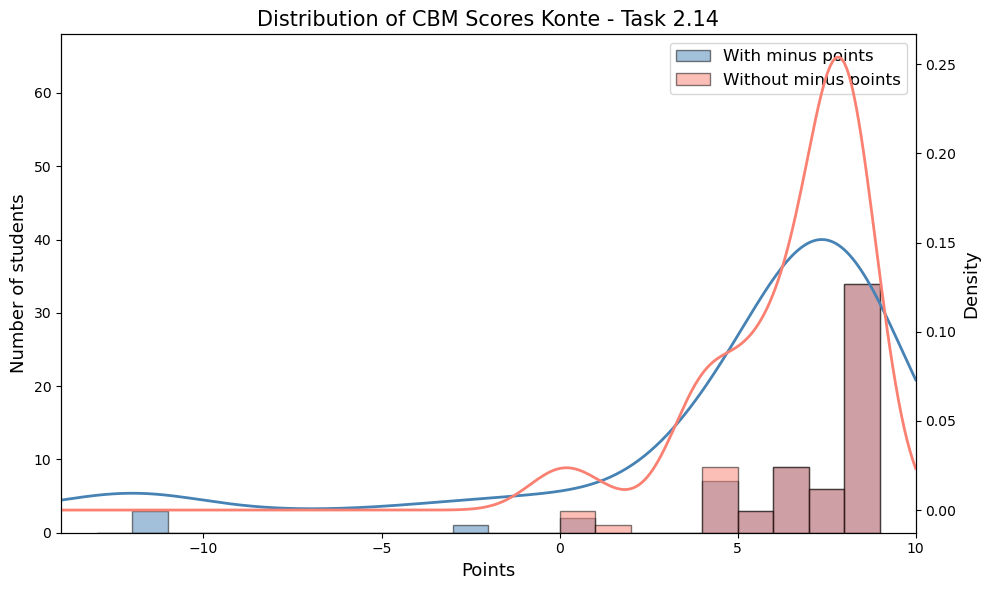

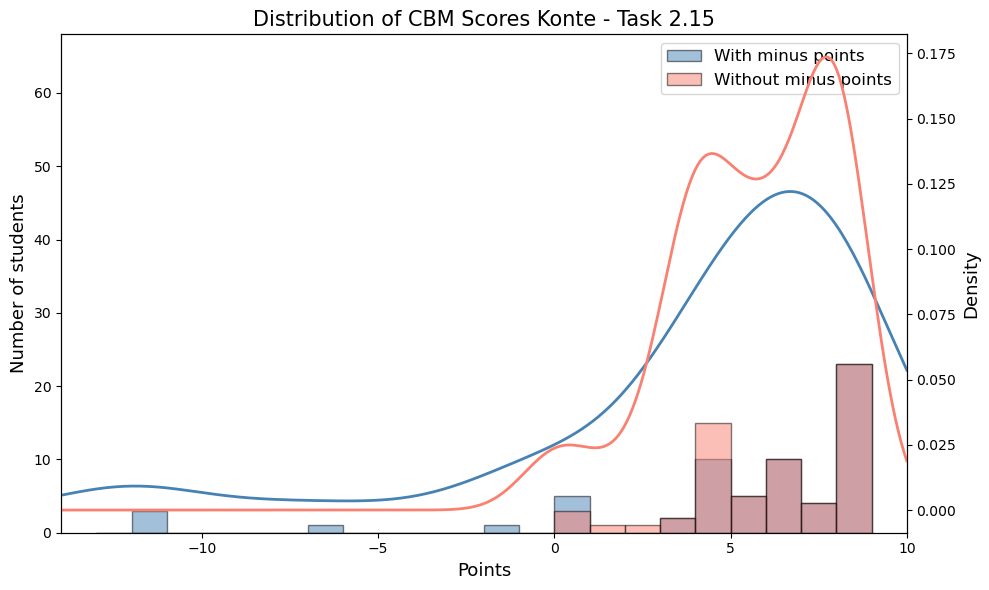

In [9]:
tasks = [f'2.{i}' for i in range(1, 16)]
map_answers = ['R', 'P', 'P', 'M', 'F']

output_dir = root_path / "analysis" / "CBM" / "2025" / "Konte" / "output" / "output_task_per_task_comparison"
output_dir.mkdir(parents=True, exist_ok=True)

# First pass: compute all scores to determine global axis limits
all_with = []
all_without = []
max_count = 0

for task in tasks:
    scores_with = CBM_score_per_task_konte_no_F(df, question_number=task, map_answers=map_answers)
    scores_without = CBM_score_per_task_konte_no_minus_points(df, question_number=task, map_answers=map_answers)
    all_with.append(scores_with['score'].values)
    all_without.append(scores_without['score'].values)

    # Track max histogram count for y-axis
    all_scores = np.concatenate([scores_with['score'].values, scores_without['score'].values])
    bins = np.arange(all_scores.min() - 1, all_scores.max() + 2, 1)
    counts_w, _ = np.histogram(scores_with['score'], bins=bins)
    counts_wo, _ = np.histogram(scores_without['score'], bins=bins)
    max_count = max(max_count, counts_w.max(), counts_wo.max())

global_min = min(np.concatenate(all_with).min(), np.concatenate(all_without).min())
global_max = max(np.concatenate(all_with).max(), np.concatenate(all_without).max())
global_bins = np.arange(global_min - 1, global_max + 2, 1)
y_limit = max_count + 5

# Second pass: plot with uniform axes
for i, task in enumerate(tasks):
    scores_with = CBM_score_per_task_konte_no_F(df, question_number=task, map_answers=map_answers)
    scores_without = CBM_score_per_task_konte_no_minus_points(df, question_number=task, map_answers=map_answers)

    merged = scores_with.merge(scores_without, on='student_id', suffixes=('_with_minus', '_without_minus'))

    col_with = 'score_with_minus'
    col_without = 'score_without_minus'

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(merged[col_with], bins=global_bins, alpha=0.5,
            label="With minus points", color="steelblue", edgecolor="black")
    ax.hist(merged[col_without], bins=global_bins, alpha=0.5,
            label="Without minus points", color="salmon", edgecolor="black")

    ax.set_xlim(global_min - 2, global_max + 2)
    ax.set_ylim(0, y_limit)

    # KDE density curves on secondary axis
    ax2 = ax.twinx()
    for col, color in [(col_with, "steelblue"), (col_without, "salmon")]:
        data = merged[col].dropna()
        if data.nunique() > 1:
            kde = gaussian_kde(data)
            x_range = np.linspace(global_min - 2, global_max + 2, 300)
            ax2.plot(x_range, kde(x_range), color=color, linewidth=2)
    ax2.set_ylabel("Density", fontsize=13)

    ax.set_xlabel("Points", fontsize=13)
    ax.set_ylabel("Number of students", fontsize=13)
    ax.set_title(f"Distribution of CBM Scores Konte - Task {task}", fontsize=15)
    ax.legend(fontsize=12)
    plt.tight_layout()

    task_label = task.replace('.', '_')
    plt.savefig(output_dir / f"CBM_{task_label}_comparison_with_vs_without_minus.png")
    plt.show()